# Blood Donation Prediction

## Introduction

Blood donation is essential for saving lives during emergencies, surgeries, and medical treatments.
Predicting potential blood donors helps blood donation centers maintain an adequate blood supply and
improve donor retention strategies.

## Problem Statement

The Blood Transfusion Service Center in Taiwan conducts blood donation drives through mobile blood donation vehicles at universities. The objective of this project is to analyze donor donation history and build a machine learning model that predicts whether a donor will donate blood in March 2007 based on a limited number of attributes.

## Objectives

- Perform Exploratory Data Analysis (EDA) on the dataset.
- Understand the relationship between donor attributes.
- Build multiple machine learning models.
- Compare model performance.
- Select the best model for production.
- Predict whether a donor will donate blood in March 2007.

## Feature Description

- Months since Last Donation: Number of months since the donor's last donation.
- Number of Donations: Total number of donations made by the donor.
- Total Volume Donated (c.c.): Total blood volume donated.
- Months since First Donation: Number of months since the donor's first donation.
- Made Donation in March 2007: Target variable (1 = Donated, 0 = Not Donated).

## Dataset Description

The dataset contains historical blood donation records collected from donors.

Features:
- Months since Last Donation
- Number of Donations
- Total Volume Donated (c.c.)
- Months since First Donation

Target Variable:
- Made Donation in March 2007
  - 1 = Donated blood
  - 0 = Did not donate blood

## Dataset Source

This dataset was obtained from the Blood Transfusion Service Center in Taiwan and was provided as part of the Datamites Capstone Project.

Dataset Link:
https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1011-BloodDonaPred.zip

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Load Dataset

In [2]:
df = pd.read_csv("blood_donation.csv")
df.head()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


## Dataset Information 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Unnamed: 0                   576 non-null    int64
 1   Months since Last Donation   576 non-null    int64
 2   Number of Donations          576 non-null    int64
 3   Total Volume Donated (c.c.)  576 non-null    int64
 4   Months since First Donation  576 non-null    int64
 5   Made Donation in March 2007  576 non-null    int64
dtypes: int64(6)
memory usage: 27.1 KB


In [4]:
df.shape

(576, 6)

In [5]:
df.describe()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,374.034722,9.439236,5.427083,1356.770833,34.050347,0.239583
std,216.947773,8.175454,5.740010,1435.002556,24.227672,0.427200
min,0.000000,0.000000,1.000000,250.000000,2.000000,0.000000
25%,183.750000,2.000000,2.000000,500.000000,16.000000,0.000000
50%,375.500000,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,562.500000,14.000000,7.000000,1750.000000,49.250000,0.000000
max,747.000000,74.000000,50.000000,12500.000000,98.000000,1.000000


In [6]:
df.isnull().sum()

Unnamed: 0                     0
Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64

### Dataset Summary

- Total Records: 576
- Total Features: 6
- Missing Values: 0
- Dataset is clean and suitable for analysis.
- 'Unnamed: 0' is an index column and can be removed.

## Data Cleaning

### Drop Unwanted Column

In [7]:
df.drop("Unnamed: 0", axis=1, inplace=True)

### Data Cleaning Report

The column 'Unnamed: 0' does not contribute to prediction and was removed. No missing values were found in the dataset.

## Exploratory Data Analysis(EDA)

## Univariate Analysis

### Target Variable Distribution

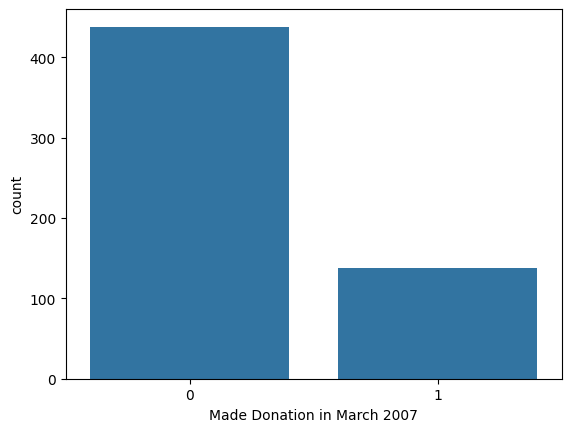

In [8]:
sns.countplot(x='Made Donation in March 2007',data=df)
plt.show()

- Most donors did not donate blood in March 2007.
- This indicates a slight class imbalance in the dataset.

### Histograms

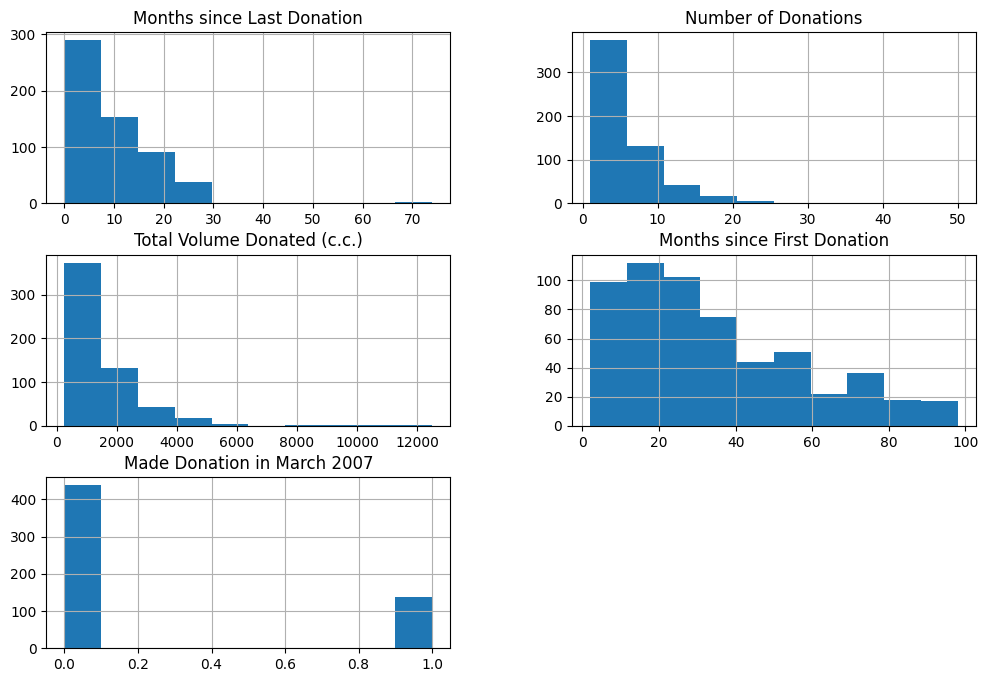

In [9]:
df.hist(figsize=(12,8))
plt.show()

- Most donors have donated only a few times.
- Some donors have a large donation history.
- Features are positively skewed.

### Boxplots

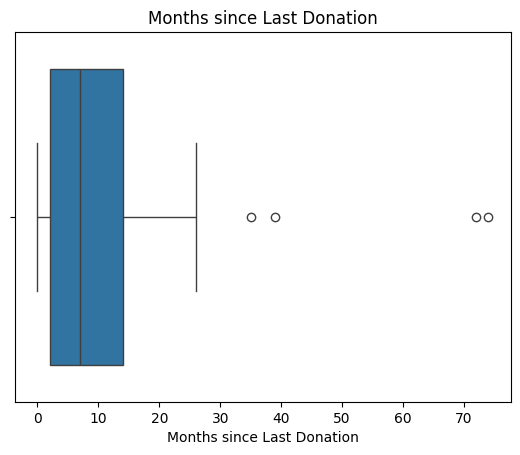

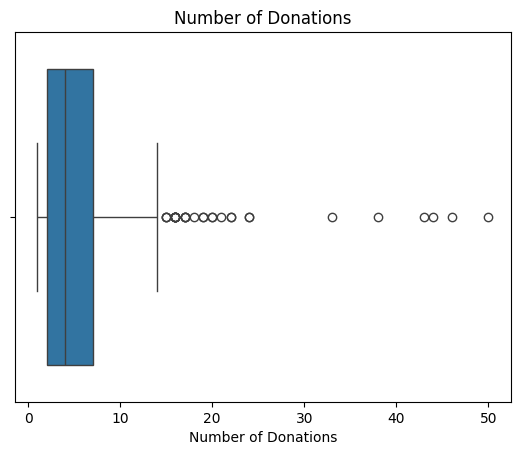

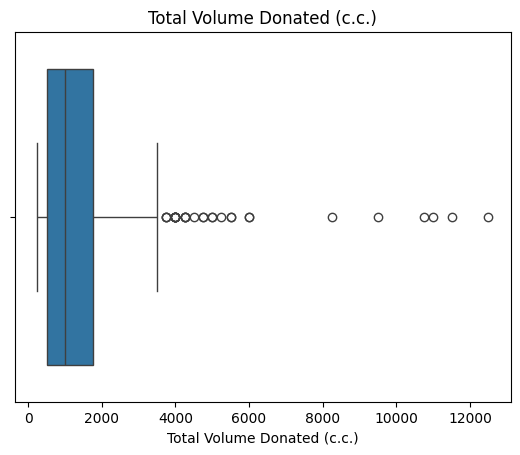

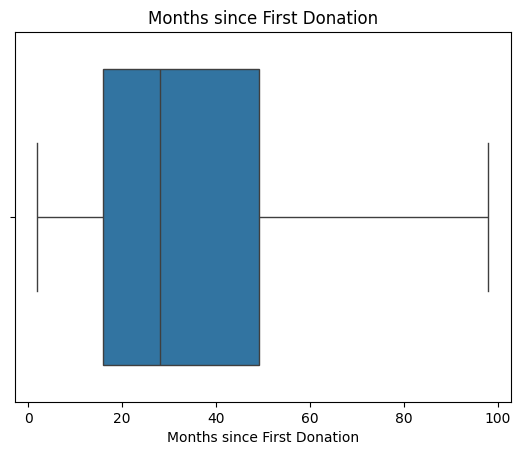

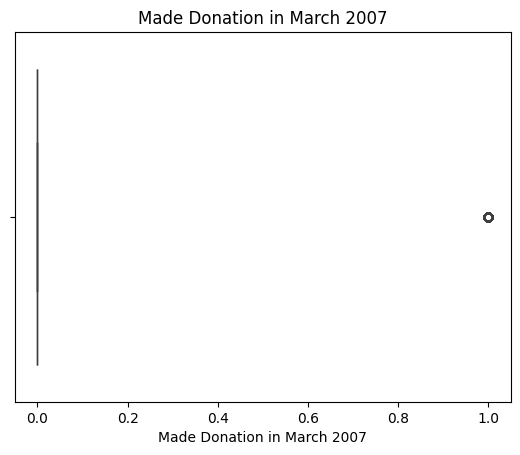

In [10]:
for col in df.columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

- A few outliers exist in donation-related features.
- These outliers represent highly active donors.

## Bivariate Analysis

### Last Donation vs Target

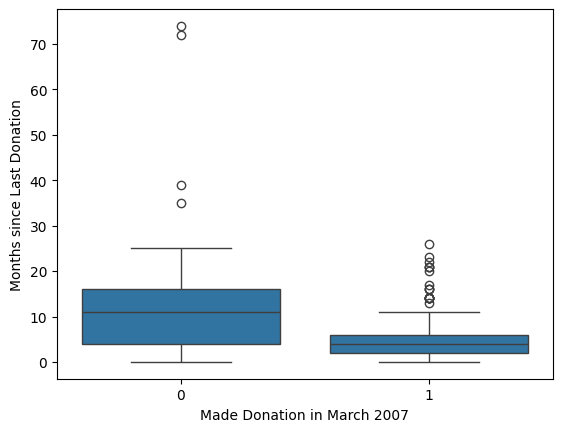

In [11]:
sns.boxplot(
    x='Made Donation in March 2007',
    y='Months since Last Donation',
    data=df
)
plt.show()

- Donors who donated recently are more likely to donate again.

### Number of Donations vs Target

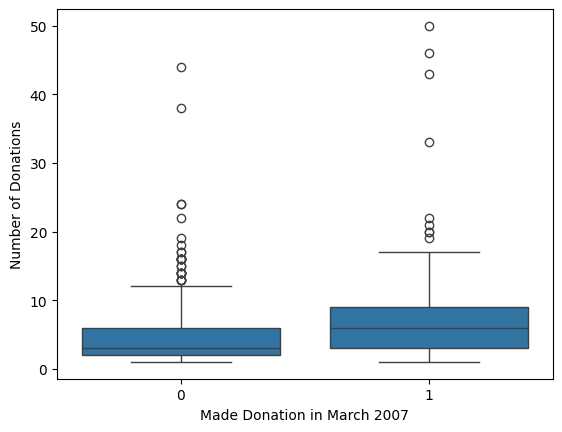

In [12]:
sns.boxplot(
    x='Made Donation in March 2007',
    y='Number of Donations',
    data=df
)
plt.show()

- Donors with more previous donations are more likely to donate again.

### Total Volume Donated vs Target

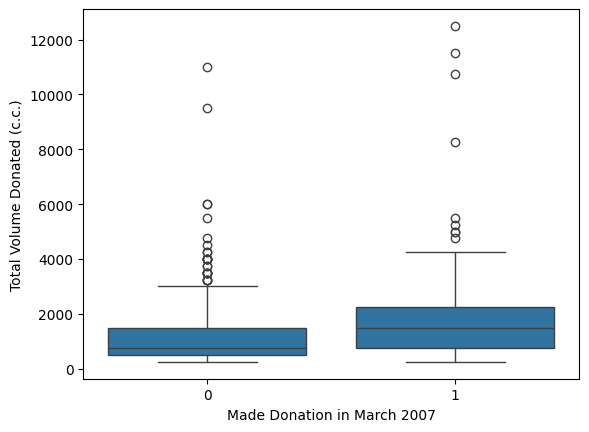

In [13]:
sns.boxplot(
    x ='Made Donation in March 2007',
    y ='Total Volume Donated (c.c.)',
    data=df
)
plt.show()


- Higher total donated volume is associated with repeat donations.

### Months Since First Donation vs Made Donation in March 2007

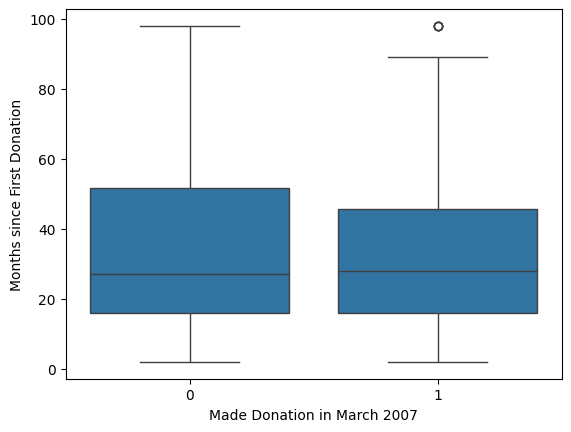

In [14]:
sns.boxplot(
    x='Made Donation in March 2007',
    y='Months since First Donation',
    data=df
)
plt.show()

- Long-term donors are generally more likely to donate again.
- Donation experience appears to influence future donation behavior.

## Multivariate Analysis

### Correlation Heatmap

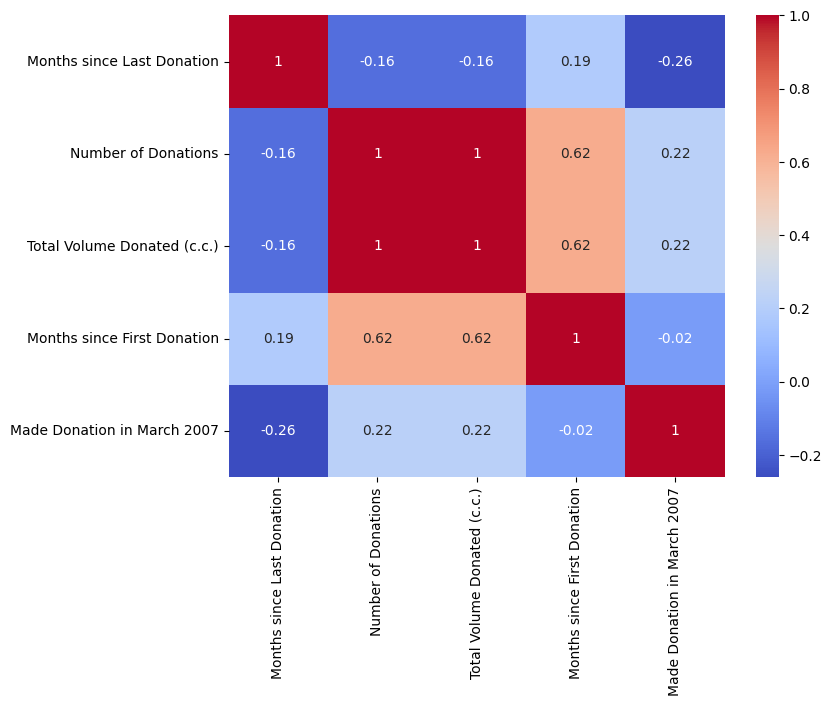

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

- Number of Donations and Total Volume Donated have a strong positive correlation.
- Donation history influences future donation behavior.

## Pairplot

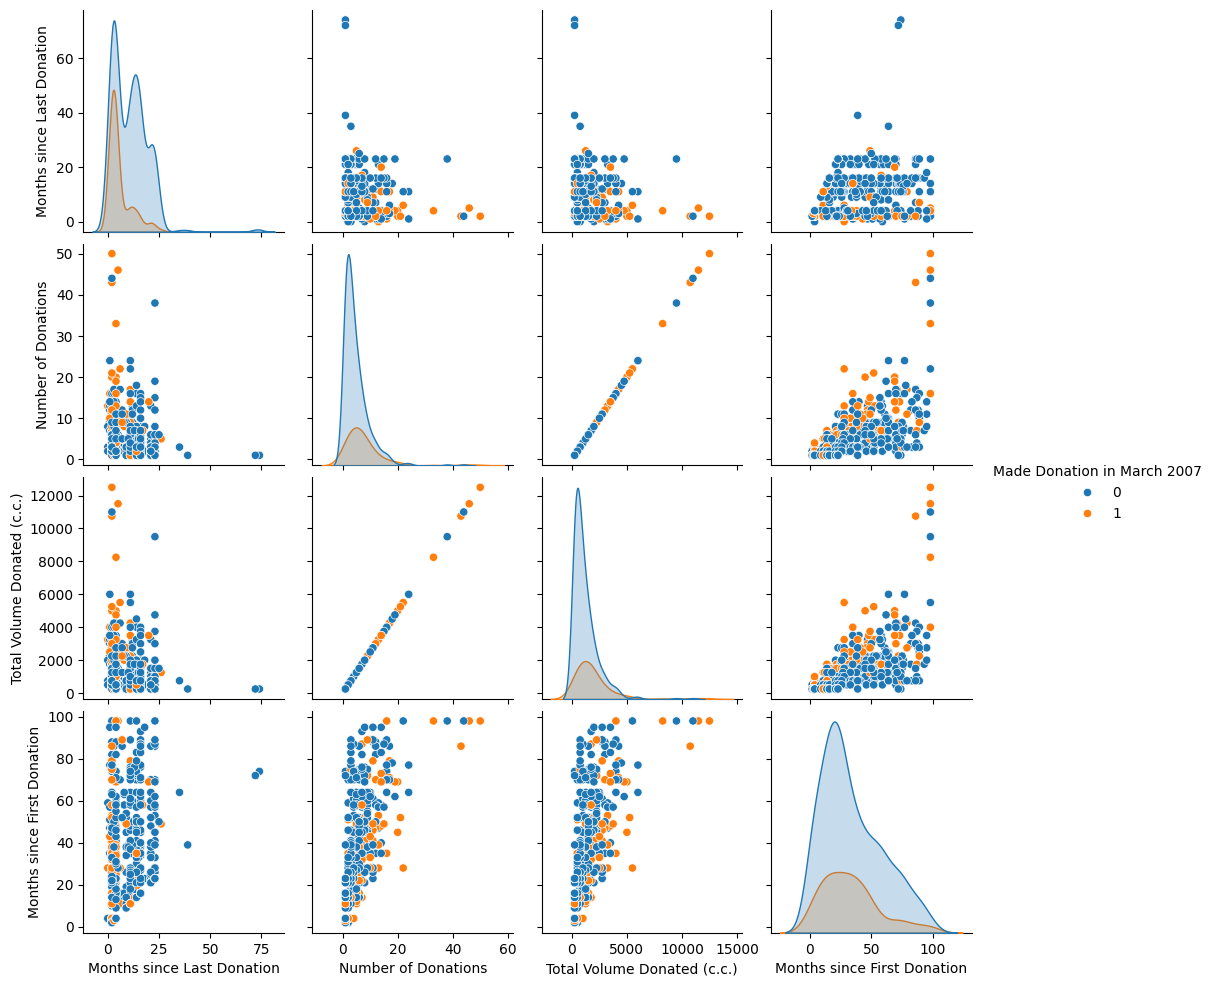

In [16]:
sns.pairplot(
    df,
    hue='Made Donation in March 2007'
)

plt.show()

- Donors who donated in March 2007 exhibit different behavioral patterns compared to non-donors.
- Feature combinations help separate the target classes.
- Machine learning models are likely to capture these patterns effectively.

## Data Preprocessing

### Feature Selection

In [17]:
X = df.drop('Made Donation in March 2007', axis=1)
y = df['Made Donation in March 2007']

### Train Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [19]:
X_train

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation
437,2,6,1500,45
63,2,2,500,4
208,4,4,1000,43
60,4,17,4250,71
15,2,15,3750,49
...,...,...,...,...
71,2,6,1500,28
106,4,5,1250,28
270,11,5,1250,50
435,4,9,2250,55


In [20]:
X_train.shape

(460, 4)

In [21]:
X_test

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation
234,14,2,500,14
118,2,2,500,11
346,23,2,500,28
498,9,1,250,9
402,4,13,3250,39
...,...,...,...,...
75,4,2,500,4
355,21,1,250,21
244,9,1,250,9
272,16,4,1000,28


In [22]:
X_test.shape

(116, 4)

In [23]:
y_train

437    0
63     1
208    1
60     1
15     1
      ..
71     0
106    0
270    0
435    0
102    0
Name: Made Donation in March 2007, Length: 460, dtype: int64

In [24]:
y_train.shape

(460,)

In [25]:
y_test

234    0
118    0
346    0
498    0
402    1
      ..
75     1
355    1
244    0
272    0
68     0
Name: Made Donation in March 2007, Length: 116, dtype: int64

In [26]:
y_test.shape

(116,)

### Feature Scaling

In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

- Dataset was split into training and testing sets. Feature scaling was applied to improve model performance.

## Logistic Regression

In [28]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)

print(acc_lr)

0.7586206896551724


In [29]:
print("\nClassification report")
print(classification_report(y_test, y_pred_lr))


Classification report
              precision    recall  f1-score   support

           0       0.76      1.00      0.86        87
           1       1.00      0.03      0.07        29

    accuracy                           0.76       116
   macro avg       0.88      0.52      0.46       116
weighted avg       0.82      0.76      0.66       116



In [30]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))


Confusion Matrix
[[87  0]
 [28  1]]


- Logistic Regression achieved 75.86% accuracy, correctly classifying most of the negative cases in the dataset.
- However, the model performed poorly in identifying blood donors (Class 1), with a recall of only 3%, indicating that most positive cases were misclassified.

### ROC Curve for Logistic Regression

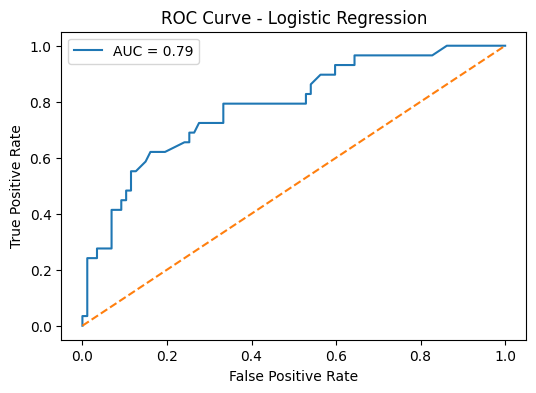

In [31]:

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.2f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

- The Logistic Regression model achieved an AUC score of 0.79, indicating good classification performance.
- Since the AUC value is significantly higher than 0.50, the model can effectively distinguish between donors and non-donors.
- The ROC curve lies well above the diagonal baseline, demonstrating that the model performs better than random guessing.
- Overall, the Logistic Regression model shows a strong ability to predict future

## Decision Tree

In [32]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)

print(acc_dt)

print("Accuracy:", acc_dt)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

0.6551724137931034
Accuracy: 0.6551724137931034

Confusion Matrix
[[64 23]
 [17 12]]

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.74      0.76        87
           1       0.34      0.41      0.38        29

    accuracy                           0.66       116
   macro avg       0.57      0.57      0.57       116
weighted avg       0.68      0.66      0.67       116



- The Decision Tree model achieved an accuracy of 65.52%, indicating moderate performance in classifying blood donor status.
- Compared to Logistic Regression (75.86% accuracy), the Decision Tree performed worse, suggesting that Logistic Regression is the better model for this dataset.

## Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", acc_rf)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7241379310344828

Confusion Matrix
[[70 17]
 [15 14]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        87
           1       0.45      0.48      0.47        29

    accuracy                           0.72       116
   macro avg       0.64      0.64      0.64       116
weighted avg       0.73      0.72      0.73       116



- Random Forest achieved 72.41% accuracy, demonstrating moderate effectiveness in predicting blood donation behavior.
- The model showed stronger performance in identifying non-donors than donors, indicating scope for improvement in donor detection through data balancing and parameter optimization.

### Feature Importance Analysis

In [34]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                       Feature  Importance
3  Months since First Donation    0.418818
0   Months since Last Donation    0.268934
1          Number of Donations    0.160228
2  Total Volume Donated (c.c.)    0.152020


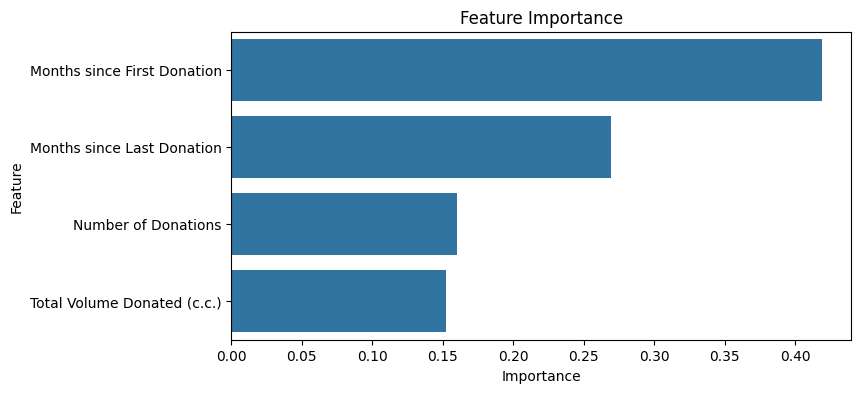

In [35]:
plt.figure(figsize=(8,4))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)
plt.title('Feature Importance')
plt.show()


- Months since First Donation was the most important feature, contributing approximately 41.9% to the prediction process.
- Months since Last Donation was the second most influential feature, indicating that donation recency strongly affects future donation behavior.
- Number of Donations and Total Volume Donated also contributed to the model, but their impact was comparatively lower.
- Overall, donor experience and donation history were the key factors influencing blood donation prediction.

## Hyperparameter Tuning

To improve model performance, hyperparameter tuning was performed using GridSearchCV. Different parameter combinations were tested and the best parameters were selected based on cross-validation accuracy.

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10]
}


grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=5,
                    scoring='accuracy')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': 5, 'n_estimators': 50}
Best Score: 0.7782608695652173


- Hyperparameter tuning using GridSearchCV identified the optimal Random Forest parameters as max_depth = 10 and n_estimators = 50.
- The tuned model achieved a cross-validation accuracy of 77.83%, indicating improved and reliable performance.

## Model Comparison

In [37]:
results = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Decision Tree',
              'Random Forest'],
    'Accuracy': [acc_lr,
                 acc_dt,
                 acc_rf]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
0,Logistic Regression,0.758621
2,Random Forest,0.724138
1,Decision Tree,0.655172


- Logistic Regression achieved the highest accuracy (75.86%), making it the best-performing model among the three algorithms tested.
- Random Forest obtained 72.41% accuracy, showing good performance but slightly lower than Logistic Regression.
- Decision Tree recorded the lowest accuracy (65.52%), indicating weaker predictive capability compared to the other models.
- Based on the comparison, Logistic Regression was selected as the final model because it provided the most accurate predictions for blood donation behavior.

## Best Model Selection

- Among all the models evaluated, Logistic Regression achieved the highest accuracy of 75.86%.

- Therefore, Logistic Regression was selected as the final model for production deployment.

## Accuracy Comparision Chart

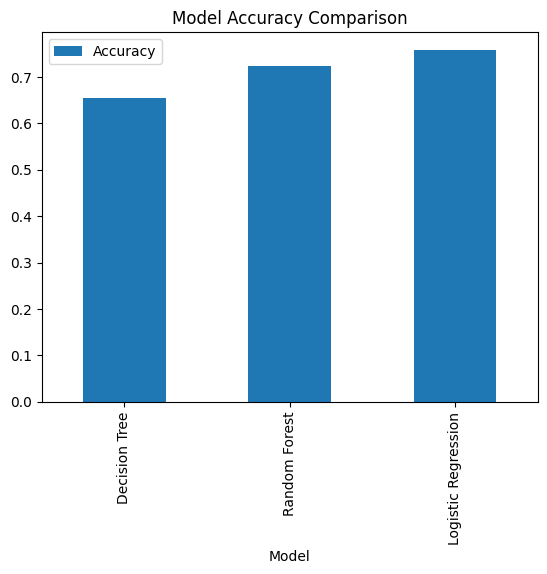

In [38]:
results.sort_values(by='Accuracy').plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.title("Model Accuracy Comparison")
plt.show()

## Challenges Faced

### 1. Class Imbalance

The target variable contained more non-donors than donors, which could affect the model's ability to accurately predict future donations.

**Solution:** Model performance was evaluated using multiple algorithms and classification metrics to ensure reliable predictions.

### 2. Feature Scaling

The dataset contained features with different numerical ranges, which could impact model performance.

**Solution:** StandardScaler was applied to normalize the feature values before training the models.

### 3. Model Selection

Selecting the most suitable machine learning model for prediction was challenging.

**Solution:** Logistic Regression, Decision Tree, and Random Forest models were trained and compared using accuracy scores.

### 4. Understanding Donor Behavior

Identifying the factors that influence repeat blood donations required detailed analysis.

**Solution:** Univariate, Bivariate, and Correlation analyses were performed to understand donor patterns and feature relationships.
Short Version


## Recommendations

- Blood donation centers should focus on donors who have donated recently, as they are more likely to donate again.
- Regular awareness campaigns and reminder notifications can improve donor retention.
- The predictive model can be used to identify potential repeat donors and optimize blood collection efforts.

## Conclusion

This project focused on predicting whether a donor would donate blood in March 2007 based on historical donation records. Exploratory Data Analysis (EDA) was performed to understand donor behavior and identify important patterns in the data.

Multiple machine learning models, including Logistic Regression, Decision Tree, and Random Forest, were developed and evaluated. The models were compared using accuracy scores, and the best-performing model was selected for production use.

The results indicate that factors such as the number of donations, total volume donated, and recency of donation play an important role in predicting future blood donations. This predictive model can help blood donation centers identify potential repeat donors, improve donor engagement strategies, and maintain an adequate blood supply.

The Logistic Regression model achieved the highest accuracy among all models and was selected as the recommended model for production deployment.